# Probabilistic Design Optimization Final Project: Trajectory Optimization Under Uncertainty for Autonomous Surface Vessel
> Ivy Mahncke
> Spring 2026

## 1 Executive Summary

In this project, I use optimization methods to find the most reliable sequence of motion control commands for an Autonomous Surface Vessel (ASV) to execute as it navigates to a given waypoint in a disturbance-heavy marine environment. I formulate the scenario as a multi-objective optimization problem where distance to waypoint and energy consumption are objective functions to minimize. I further constrain the problem by designating off-limits areas and defining physical motion constraints for the ASV. I also model uncertainty present in the environment and the ASV's motion to optimize for reliability and robustness metrics. In a deterministic, multi-objective model, the optimizer successfully converges on a control sequence that produces an efficient and physically feasible trajectory to the waypoint, even in scenarios where heavy environmental disturbances are present. When the model is probabilistic and uncertainty is present, the optimizer successfully converges on a control sequence that produces a trajectory with minimal expected distance and energy costs to the waypoint, across an set of scenarios generated by Monte Carlo sampling. Afterwards, I evaluate the model's performance in the wider context of a full autonomy stack operating a real-world robotic platform. Finally, I consider the ethical implications of the model's performance, limitations of the model, and potential future work.

## 2 Background

In this section, the broader context of the usefulness of robotic platforms in marine environments is outlined. The specific piece of the autonomy stack that this model represents is contextualized within a wider autonomous navigation system. Additionally, the utility of optimizing the model's performance is discussed. Afterwards, specific stakeholder concerns and priorities are mapped to quantative and qualitative model features.  Finally, the background and contextual information described in the section is summarized using a detailed Tenchi Diagram.

### 2.1 Problem Context - Marine Environmental Monitoring with Robotic Platforms

Regular monitoring of marine environments is a vital practice for ocean and climate research; however, it is difficult and costly to perform by hand. Diving expertise is rare and costly for just a single mission, and diving is a dangerous practice for even the best divers around. Furthermore, marine environments change so quickly with time that data can become outdated even six months after an initial set of samples. These complications make the monitoring of marine environments a perfect candidate for a robust autonomous solution.

However, solving the monitoring problem with autonomy comes with its own difficulties. Specifically, marine environments are physically dynamic. Environmental disturbances like wind and current, which can vary on the order of minutes, prevent a single predefined ASV trajectory from consistently gathering worthwhile data. Therefore, any autonomous system attempting to navigate in a marine environment must be robust to the highly dynamic forces present on an ocean surface.

Autonomous Surface Vessels, or ASVs, are boatlike robotic platforms that are well-equipped to perform exploratative, navigation-based tasks in marine environments. Typically robotic systems like ASVs will have a global planner (to select desirable waypoints), a local planner (to find feasible and efficient paths between waypoints), and a controller (to keep the platform on track while in transit). It is the controller's responsibility to react and respond to environmental disturbances in a real-time, closed-loop manner, while the global planner does not generally consider these factors in waypoint selection. However, a local planner capable of generating a nominal, disturbance-aware trajectory to the next waypoint can ease the strain on the controller to fight aggressive dynamics in transit. Since the environmental disturbances are so deeply uncertain, an excellent local planner would generate a nominal trajectory that is optimal for the range of disturbances expected to be present in the environment.

This project attempts to characterize, model, and validate a local planner system for generating an optimal nominal set of motor commands in a specific local environment. This system would be used in conjunction with a broader autonomous navigation stack: in particular, with a global planner that supplies an initial state and desired waypoint, and with a controller that will build on the local planner's nominal commands in a real-time, closed-loop format. If the local planner can find optimal sets of commands for expected disturbance scenarios, the strain on the controller later will be relieved substantially, and the ASV will more efficiently navigate the waypoints established by the global planner.

### 2.2 Stakeholders, Requirements, and Objectives

Three key stakeholders guide the priorities and objectives of the model design:

**A) Shore Research Team.**

This stakeholder group represents lab-based researchers with investments (monetary, academic, etc.) in the continued success of the ASV's environmental monitoring missions. Their primary concern is consistency and reliability in the ASV's ability to gather useful data across deployments. Regardless of how much environmental conditions change from deployment to deployment, the shore research team expects a "no repeats" system in which the system is capable of reaching every waypoint within a single run.

**B) Field Deployment Team.**

This stakeholder group represents the field researchers responsible for safely deploying, monitoring, and retrieving the ASV on the water. Their primary concern is safety of the ASV and of any other agents operating near the ASV, such as recreational boaters, swimmers, and more. The field deployment team is willing to miss out on important data in a given run if collecting that data endangers the ASV or anyone else. As a facet of safety, the field deployment team has a vested in the ASV executing an energy-efficient set of commands that does not waste energy needlessly. As an additional concern, the field deployment team has a limited amount of time available to participate in any given deployment; as such, the ASV's missions are all inherently time-constrained.

**C) Marine Wildlife & Ecosystem.**

This stakeholder group represents marine animals, plants, geological formations, water, and any other component of the natural ecosystem that the ASV is attempting to monitor. This group's primary concern is to experience minimal disruption from the process of being monitored by an ASV. While the intent of the ASV's data collection is ultimately to benefit the ecosystem's health, it is critical that the process of that data collection doesn't undermine the overall goal. As a result, the ecosystem benefits from a nondisruptive, nonpolluting, and quiet monitoring system.

From these three stakeholder groups' concerns and investments, the following objectives can be derived:

- *Waypoint completion:* nominal trajectory reduces the expected distance between the ASV and the waypoint as much as possible
- *Time efficiency:* nominal trajectory reduces the time taken for the ASV to reach the waypoint as much as possible
- *Energy efficiency:* nominal trajectory reduces the energy consumed to get the ASV to the waypoint as much as possible

Additionally, the following constraints derived from stakeholder concerns will be applied to the model:

- *Time constraint:* the number of timesteps cannot exceed a given number
- *Position constraint:* the ASV cannot enter any areas defined as off-limits
- *Motor speed constraint:* the motor commands (linear velocity, angular velocity) cannot exceed specific limits on speed

Finally, the following system qualities cannot be formulated into mathematical priorities of this particular model, but are still worth denoting given the broader context and will be discussed in a later section:
- Overall reliability of the local planner across all global planner waypoints
- Quality of data gathered by the ASV during a given deployment
- Environmental harm of ASV operation beyond motor speeds

### 2.3 Tenchi Diagram

<img src="./images/final_tenchi.png" width="600">

## 3 Formulation - Optimization Problem

### 3.1 Objective Function

The objective function describes the multi-objective minimization of A) cumulative distance from the ASV's position at all times to the waypoint, and B) approximate energy expended by the ASV at the point of mission completion.

$$min f(u)=E[J_{distance}]+E[J_{energy}]$$

where:

$$J_{distance}=\sum_{k=0}^N||(p_{x,k}-w_x)||_2$$

$$J_{energy}=\sum_{k=0}^{N}(v_k^2 + \omega_k^2)$$

Optimizing for cumulative distance incentivizes the model to approach the waypoint quickly and aggressively, while optimizing for energy consumption incentivizes the model to only execute aggressive motor commands when necessary. Since the expected timespan of the scenario that the model captures is small (<1min) in comparison to the broader navigational context (1+hrs), it is unnecessary to explicitly model energy consumption on an electrical level. Instead, the model abstracts energy consumption as a function of the magnitude of motor commands, squared (to discourage aggressive maneuvers).

### 3.2 Decision Variables

The decision variable driving the optimization is the sequence of control vectors that dictate the ASV's motion in physical space. The control vector contains a linear velocity term and an angular velocity term.

w.r.t.

$$u=[u_0:u_N]$$
$$u_k=(v_k,\omega_k)$$

### 3.3 Constraints

The optimization is constrained by several factors, including off-limits regions of physical space, limitations on elapsed time, and bounds on control vector values.

s.t.

$$k \leq N$$

$$p \notin P_{off-limits}$$

$$|v_k|\leq v_{max}$$

$$|\omega_k|\leq \omega_{max}$$

### 3.4 Uncertainty

This model considers uncertainty where it is pertinent to the reliability and robustness of the model in the real-world. Uncertainty is present in the model via natural variation in environmental disturbances and noise in motor output. Some sources of uncertainty, including waypoint position relative to deployment point and location of any nearby obstacles, would be handled by modules outside of the local planner (by a global planner and an obstacle detection module, respectively). Therefore, those features are considered deterministic within this model. Each source of uncertainty can be characterized by whether its cause is assignable and whether its source is real.

| Source&darr; Cause&rarr; | Chance | Assignable |
| -------- | -------- | ------- |
| **Erroneous** | Motor signal noise | N/A |
| **Real** | Magnitude and angle of disturbance | Relative location of obstacles & waypoint |

## 4 Formulation - Model Details

In this section, the design and implementation details of the model are described in natural language, equations, and code. First, the deterministic model is described alongside its underlying system kinematics. The deterministic model undergoes a verification process to ensure that the design and implementation properly represents the intended model. Additionally, the deterministic model undergoes a validation process to ensure that the intended model is reflective of expected, existing trends in the real world. Finally, after verification and validation, sources of uncertainty are characterized, applied to the model to make it probabilistic, and propagated through the model to influence objective function outcomes.

In [ ]:
import grama as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
DF = gr.Intention()

# constants
DT = 0.1 # sec
total_time = 5 # sec
timesteps = int(total_time/DT)
tol = 1e-2

# parameters
deployment_state = (0.0, 0.0, 0.0) # x, y, theta
waypt = (4.0, 4.0) # x, y

# constraint values
V_MAX = 3.0 # m/s
W_MAX = 3.0 # rad/s

# default deterministic disturbance values
DET = False
D_MAG = 0.5
D_ANG = math.pi/2

As a note, helper functions defined in external Python files will be used in this project to more clearly communicate certain complicated programmatic actions. To view their functionality in more detail, please see the code appendix at the end of the notebook.

In [84]:
import utils.visualization as viz
import utils.verification as ver
import utils.validation as val

### 4.1 Modeling ASV Kinematics

The objective function is minimized by a sequence of control vectors, but the ASV's success is defined by its sequence of positions, which is a related but not identical value. Kinematic equations relate the ASV's position to control vectors as well as environmental disturbances. As such, all variables referenced here represent actual values, rather than values measured or intended by the ASV, unless stated otherwise.

#### 4.1a State Spaces

State spaces describe sets of variables that collectively describe a key attribute about a model. The state spaces below act as a key to relate individual variables and the behaviors they influence together.

The ASV state describes key values about the ASV's position, orientation, and motion in physical space. It is comprised of the ASV's x position, y position, heading, linear velocity, and angular velocity.

$$x_k=[p_x, p_y, \theta]$$
The ASV control vector describes the ASV's intention of movement, which is imperfectly executed by motors in the physical world. It is comprised of the ASV's commanded linear velocity (driven by a forward thruster) and angular velocity, (driven by a motorized rudder).

$$u_k=(v_k,\omega_k)$$
The environmental disturbance vector describes the environment's physical influence on the ASV's motion, modeled as velocity. It is comprised a magnitude and angle, which can be broken down into an x and y component.

$$d_k=d_{x,k}+d_{y,k}=|d_k|cos(\angle d)+|d_k|sin(\angle d)$$

#### 4.1b Motion Kinematics

These are the set of equations governing the ASV's state transition after each timestep. These relate the ASV's next state to its current state, control vectors, and active disturbances.

$$p_{x,k+1}^{}=p_{x,k}+(v_{k,noisy}cos(\theta_k)+d_x)*dt$$

$$p_{y,k+1}=p_{y,k}+(v_{k,noisy}sin(\theta_k)+d_y)*dt$$

$$\theta_{k+1}=\omega_{k,noisy}*dt$$

Below, the actual state transition model is defined programatically for future use in deterministic and probabilistic simulation.

In [91]:
def det_state_transition(init_state: tuple[float,float,float],input_vec: pd.Series,d_mag=D_MAG,d_ang=D_ANG):
    """
    Helper function to perform state transitions from an initial state using a control vector and random variables.

    This is a deterministic function that does not account for sampled uncertainty values.
    """
    # grab initial state
    states = [init_state]

    # grab sequential control vectors
    lin_vels = [float(input_vec[f"v{k}"]) for k in range(timesteps)]
    ang_vels = [float(input_vec[f"w{k}"]) for k in range(timesteps)]

    # iterate through control vector
    for vk, wk in zip(lin_vels, ang_vels):
        # state variables
        xk, yk, thk = states[-1]

        # disturbance in xy
        d_ang_flip = d_ang + math.pi
        d_ang_wrap = np.arctan2(np.sin(d_ang_flip), np.cos(d_ang_flip))
        d_x = d_mag*math.cos(d_ang_wrap)
        d_y = d_mag*math.sin(d_ang_wrap)

        # kinematics
        xk1 = xk + DT*(vk*math.cos(thk) + d_x)
        yk1 = yk + DT*(vk*math.sin(thk) + d_y)
        thk1 = thk + DT*(wk)
        thk1 = np.arctan2(np.sin(thk1), np.cos(thk1)) # wrap to [-pi, pi]

        # iterate state
        states.append((xk1, yk1, thk1))
    
    # return final state sequence
    return states

def prob_state_transition(init_state: tuple[float,float,float],input_vec: pd.Series,):
    """
    Helper function to perform state transitions from an initial state using a control vector and random variables.

    This is a probabilistic function that accounts for sampled certainty values.
    """
    # grab initial state
    states = [init_state]

    # grab sequential control vectors
    lin_vels = [float(input_vec[f"v{k}"]) for k in range(timesteps)]
    ang_vels = [float(input_vec[f"w{k}"]) for k in range(timesteps)]

    # grab noise values
    lin_vel_noises = [float(input_vec[f"v{k}_noise"]) for k in range(timesteps)]
    ang_vel_noises = [float(input_vec[f"w{k}_noise"]) for k in range(timesteps)]
    d_mags = [float(input_vec[f"d_mag{k}"]) for k in range(timesteps)]
    d_ang = input_vec["d_ang"]

    # iterate through control vector
    for vk, wk, vk_noise, wk_noise, d_magk in zip(lin_vels, ang_vels, lin_vel_noises, ang_vel_noises, d_mags):
        # state variables
        xk, yk, thk = states[-1]

        # disturbance in xy
        d_ang_flip = d_ang + math.pi
        d_ang_wrap = np.arctan2(np.sin(d_ang_flip), np.cos(d_ang_flip))
        d_x = d_magk*math.cos(d_ang_wrap)
        d_y = d_magk*math.sin(d_ang_wrap)

        # apply motor noise
        vk = vk + vk_noise
        wk = wk + wk_noise

        # kinematics
        xk1 = xk + DT*(vk*math.cos(thk) + d_x)
        yk1 = yk + DT*(vk*math.sin(thk) + d_y)
        thk1 = thk + DT*(wk)
        thk1 = np.arctan2(np.sin(thk1), np.cos(thk1)) # wrap to [-pi, pi]

        # iterate state
        states.append((xk1, yk1, thk1))
    
    # return final state sequence
    return states

### 4.2 Defining the Deterministic Model

The state transition helper function the only thing necessary to define the objective functions, and ultimately, the deterministic model. Below, the two objective functions are defined programatically. As a reminder, the first objective function calculates the cumulative distance over time between the ASV and the waypoint. The second objective function calculates an approximation of the total energy consumption during the mission timespan.

In [12]:
# primary objective functions
def D_total_distance(input_vec):
    """
    Vectorized function to calculate the D (cumulative distance from waypoint across time) column of a scenario row.
    """
    # sum distance
    sum_distance = 0

    # perform state transition
    if DET:
        state_sequence = det_state_transition(deployment_state,input_vec)
    else:
        state_sequence = prob_state_transition(deployment_state,input_vec)

    # iterate through state sequence
    for s in state_sequence:
        # state variables
        xk, yk, _ = s

        # add to sum distance
        sum_distance += np.sqrt((xk-waypt[0])**2 + (yk-waypt[1])**2)
    
    # return raw distance from state to waypoint
    return sum_distance

def J_final_energy(input_vec):
    """
    Vectorized function to calculate the J (final energy) column of a scenario row.
    """
    # relative energy consumption
    relative_energy = 0.0

    # grab sequential control vectors
    lin_vels = [float(input_vec[f"v{k}"]) for k in range(timesteps)]
    ang_vels = [float(input_vec[f"w{k}"]) for k in range(timesteps)]
    
    if DET:
        # square all velocities
        for vel in lin_vels + ang_vels:
            relative_energy += vel**2
    else:
        # grab noise values
        lin_vel_noises = [float(input_vec[f"v{k}_noise"]) for k in range(timesteps)]
        ang_vel_noises = [float(input_vec[f"w{k}_noise"]) for k in range(timesteps)]

        # iterate through velocities
        for vk, wk, vk_noise, wk_noise in zip(lin_vels, ang_vels, lin_vel_noises, ang_vel_noises):
            relative_energy += (vk + vk_noise)**2
            relative_energy += (wk + wk_noise)**2
    
    # return total relative energy
    return relative_energy

Next, the deterministic model is implemented in `py-grama`. The deterministic model contains both objective functions vectorized with respect to the control vector as a list of decision variables, where each variable represents either a linear velocity or angular velocity at a particular timestep. Additionally, the model applies maximum velocity constraints to each decision variable.

In [13]:
# grama variable vectors
controls = [f"w{int(k/2)}" if k % 2 == 0 else f"v{int(k/2)}" for k in range(timesteps*2)] # lin vel, ang vel
objectives = ["D", "J"] # cumulative distance, energy consumed
states = [f"x{k}" for k in range(timesteps)] # state (x, y, theta)

def model_trajectory(df_in: pd.DataFrame):
    """
    DataFrame-based method of extracting objective function values from a given control input sequence.

    Args:
        df_in: A DataFrame in which each column represents a decision variable or a random variable.

    Returns:
        df_out: A DataFrame in which each column represents an objective function value.
    """
    # establish the out dataframe
    df_out = pd.DataFrame()
    
    # establish vectorized functions for objectives
    df_out["D"] = df_in.apply(D_total_distance,axis="columns")
    df_out["J"] = df_in.apply(J_final_energy,axis="columns")

    # return
    return df_out

# define the deterministic ASV kinematic model (constrained, multi-objective)
md_asv_det = (
    # name model
    gr.Model("ASV Motion Kinematics")
    # state transition kinematics
    >> gr.cp_vec_function(
        fun=model_trajectory,
        var=controls,
        out=objectives,
    )
    # constrain linear velocity commands
    >> gr.cp_bounds(
        **{f"v{k}": (-0.0, +V_MAX) for k in range(timesteps)}
    )
    # constrain angular velocity commands
    >> gr.cp_bounds(
        **{f"w{k}": (-W_MAX, +W_MAX) for k in range(timesteps)}
    )
)

### 4.3 Model Verification & Validation

#### 4.3a Model Verification

Now that the deterministic model is constructed, steps are taken to verify its functionality. Verification for this model is in the form of unit tests which confirm that individual functions within the model are working properly. Below, all `assert` statements passing indicates that the model has been verified.

In [ ]:
ver.run_all_tests(det_state_transition)

[PASS] output length is timesteps+1
[PASS] initial state preserved as first element
[PASS] zero inputs + zero disturbance = no motion
[PASS] pure linear velocity at heading=0 moves only in +x
[PASS] zero linear velocity + angular velocity = rotation only
[PASS] heading wraps within [-pi, pi]
[PASS] D_ANG=0 (wind from east) pushes ASV in -x
[PASS] D_ANG=pi/2 (wind from north) pushes ASV in -y
[PASS] disturbance displacement scales linearly with D_MAG
[PASS] non-origin initial state with heading=pi/2 moves in +y

10/10 tests passed


#### 4.3b Deterministic Model Validation

To validate the deterministic model, its performance will be examined under several standard environmental conditions in which the real-world optimal approach would be clear. In each scenario, the model is evaluated under a deterministic environmental disturbance vector in which the magnitude set to `0.5m` and the direction is parallel to one of the four cardinal directions. Two of the directions (west-blowing and south-blowing) are considered obstructive in that they push the ASV generally away from the waypoint, while the other two directions (east-blowing and north-blowing) are considered assistive in that they push the ASV generally toward the waypoint.

In the obstructive cases, the model is considered to be valid if it meets the following conditions, which would be true of any reasonable attempt at optimality:
- The ASV moves toward the waypoint along a smooth, spline-based trajectory (widely considered kinematically optimal for ASVs and boats)
- The ASV's heading indicates that the ASV is fighting (obstructive) or utilizing (assistive) the present disturbance in its transit
- Upon reaching the waypoint, the ASV drives into the direction of the disturbance at the same rate as the disturbance magnitude

These conditions indicate optimality in the selected command vector due to its efficient minimization of both waypoint distance and energy consumption.

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


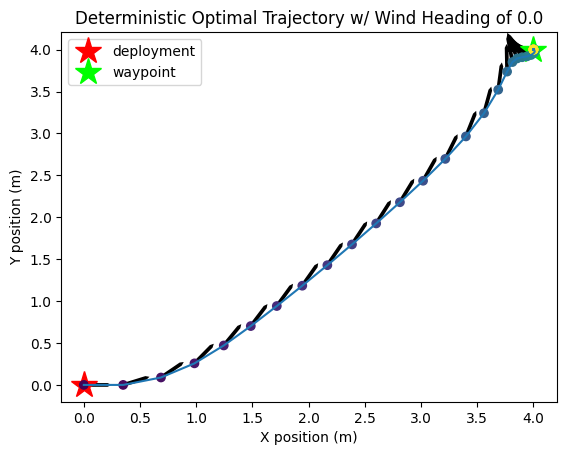

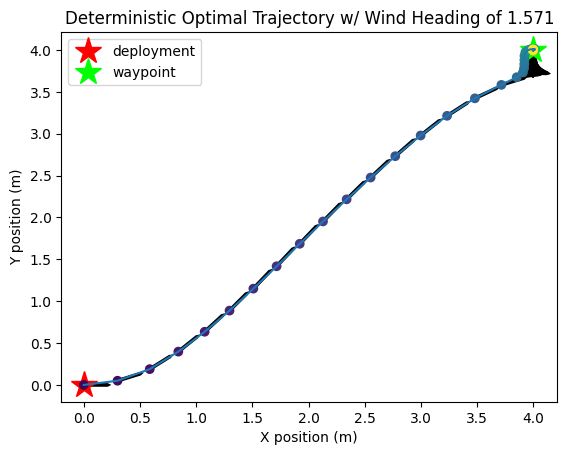

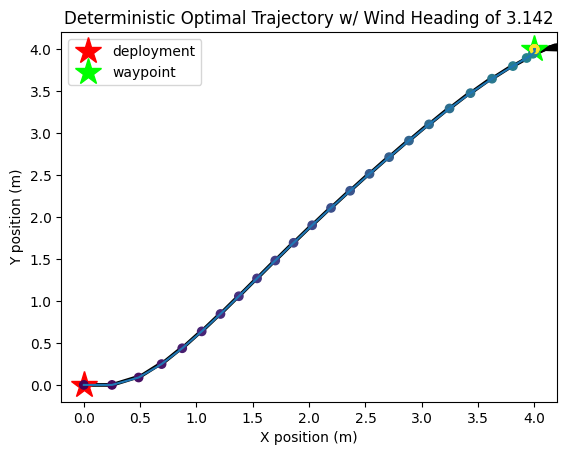

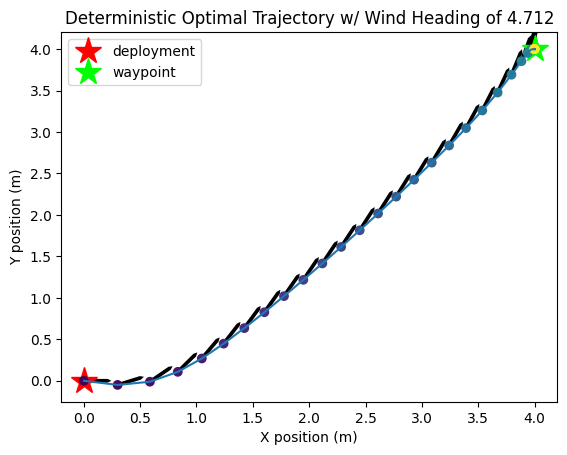

In [104]:
# %%capture
import warnings
warnings.filterwarnings('ignore')

test_d_angs = [k*math.pi/2 for k in range(4)]

val.perform_validation(test_d_angs)

In each case, the deterministic model seems to react properly to the given wind direction, regardless of if it is obstructive or assistive. Furthermore, each control vector creates a trajectory that meets the conditions outlined above for physically feasible paths comparable to real-world optimal trajectories.

### 4.4 Modeling Uncertainty

Now that the deterministic model has been verified and validated, the next step is to inject and propagate uncertainty through the model. TO start, we define key sources of uncertainty and model them as distributions grounded in the real world. To revisit, here are the central sources of uncertainty considered by the model.

| Source&darr; Cause&rarr; | Chance | Assignable |
| -------- | -------- | ------- |
| **Erroneous** | Motor signal noise | N/A |
| **Real** | Magnitude and angle of disturbance | Relative location of obstacles & waypoint |

#### 4.4a Obstacle & Waypoint Locations

While both of these situation-specific points could potentially be modeled as anomolous uncertainty, the knowledge that the local planner would have of each comes from other modules in the autonomy stack. For example, the location of the local planner's next waypoint is chosen by the global planner, meaning that in a full-stack context, the local planner could expect to know its location concretely rather than probabilistically model it. As for obstacles, the local planner's awareness of any obstacles would also come from an external autonomy module; specifically, some type of sensor-based obstacle detector. In this case, the precise location of a given obstacle is likely somewhat obscured by the noise of the sensors used to find it. However, since our model is intended to be agnostic to other modules in a hypothetical autonomy stack, it makes more sense to assume that the location of any obstacle is deterministic rather than characterize its hypothetical uncertainty poorly.

#### 4.4b Motor Signal Noise

Motor signal noise represents the random discrepancy between a navigation module or controller's intended signal output, and what physically occurs in the real world. In the case of the model, this noise is the discrepancy between selected decision variables (linear velocity and angular velocity) and their value in a kinematic state transition.

Commonly, motor signal noise would be modeled as a distribution fit to data derived from experimental testing with physical hardware. This is because modeling all underlying sources of noise in the complex electrical hardware driving the motor would be impossible. However, the [Central Limit Theorem](https://en.wikipedia.org/wiki/Central_limit_theorem) can be used to show that any distribution which is a product of several underlying, potentiall non-Gaussian distributions will generally itself be Gaussian. Therefore, in lieu of any available experimental data regarding standard ASV motors, the model approximates all motor signal noise as samples from a Gaussian distribution, with a mean centered on the intended motor output value and a somewhat small variance (implying reliable motor performance).

$$v_k^{actual}=v_k^{cmd}+\mathcal{N}(0,0.10)$$
$$\omega_k^{actual}=\omega_k^{cmd}+\mathcal{N}(0,0.10)$$

eval_sample() is rounding n...
Estimated runtime: 0.0000 sec


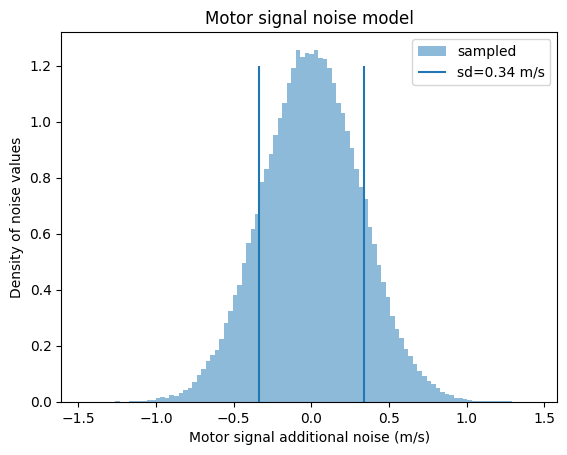

In [22]:
# model motor noise
md_motor_noise = (
    gr.Model()
    >> gr.cp_marginals(
        direction=gr.marg_mom(
            dist="norm",
            mean=0,
            var=0.10,
        )
    )
    >> gr.cp_copula_independence()
)

# sample the distribution
df_motor_noise = (
    md_motor_noise
    >> gr.ev_sample(n=1e5, df_det="nom", skip=True, seed=101)
    >> gr.tf_mutate(id=DF.index)
)
# plot wind direction variation
plt.figure()

plt.hist(df_motor_noise["direction"], bins=100, density=True, alpha=0.5, label="sampled")
plt.vlines([0.34,-0.34],0,1.2,label="sd=0.34 m/s")

plt.legend()
plt.xlabel("Motor signal additional noise (m/s)")
plt.ylabel("Density of noise values")
plt.title("Motor signal noise model")
plt.show()

#### 4.4c Environmental Disturbance Deviation

Wind and current, which together comprise the environmental disturbance velocity, are both highly variable features that depend on extremely local conditions such as temperature, season, water depth, atmospheric patterns, and more. As such, there is not a way to reasonably model environmental disturbance as a distribution in a physically grounded way. Instead, the model must again rely on sampled data to represent deviation in the natural world.

[Wind roses](https://en.wikipedia.org/wiki/Wind_rose) are graphical representations of sampled wind patterns in specific, highly local regions. They visualize the distribution of wind magnitude and direction for a given location, such as a city or an airport. Here are a few examples of wind roses representing coastal cities in North America:

<img src="./images/formulation/wr_boston.png" width="400"/>
<img src="./images/formulation/wr_sanjuan.png" width="400" />
<br>
<img src="./images/formulation/wr_vancouver.png" width="400" />
<img src="./images/formulation/wr_monterey.png" width="400" />

###### Source: [meteoblue](https://content.meteoblue.com/en/about-us)

No two wind roses are alike, so the model cannot hope to represent them all. However, we can assert that it would be reasonable for model users to modify this part of the model depending on their region of operation.

For this report, the model will use the Monterey wind rose as a basis for modeling environmental disturbance, as a nod to the [research institute](https://www.mbari.org/our-work/technologies/vehicles/) conducting marine robotics development there. Also, since current is largely a function of wind in shallow regions such as the Monterey Bay, it is reasonable to use the wind rose alone to represent all disturbance present.

<img src="./images/formulation/wr_monterey.png" width="500" class="center"/>

In [23]:
# approximate hours per wind direction; extracted from wind rose
monterey_data = {
    0*math.pi: 200, # 0pi
    1*math.pi/8: 150,
    2*math.pi/8: 90,
    3*math.pi/8: 50,
    4*math.pi/8: 50, # pi/2
    5*math.pi/8: 90,
    6*math.pi/8: 150,
    7*math.pi/8: 500,
    8*math.pi/8: 800, # pi
    9*math.pi/8: 700,
    10*math.pi/8: 300,
    11*math.pi/8: 200,
    12*math.pi/8: 150, # 3pi/2
    13*math.pi/8: 200,
    14*math.pi/8: 200,
    15*math.pi/8: 300,
}

# directions with more hours are proportionally more frequent
monterey_data_df = pd.DataFrame({
    "angle": np.repeat(list(monterey_data.keys()), list(monterey_data.values()))
})

Mathematically modeling environmental disturbance involves accounting for both magnitude and direction. Examining the Monterey wind rose reveals a direction distribution spanning all directions $[0,2\pi]$, with a strong skew towards the $\pi$ (west-to-east) direction. Below, two attempts at fitting a distribution are shown. The first is a Gaussian directly fitted to the data, while the second is a Gaussian that has been manually fit to better represent the strong skew towards the west-to-east direction.

eval_sample() is rounding n...
Estimated runtime: 0.0000 sec
eval_sample() is rounding n...
Estimated runtime: 0.0000 sec


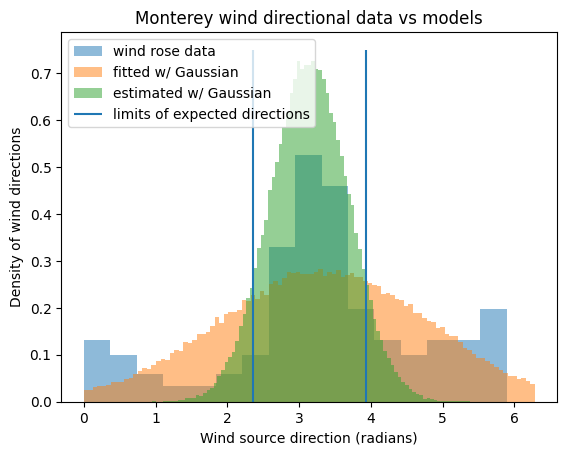

In [24]:
# fit distribution to direction data
md_wind_direction_1 = (
    gr.Model()
    >> gr.cp_marginals(
        direction=gr.marg_fit(
            dist="norm",
            data=monterey_data_df.angle,
        )
    )
    >> gr.cp_copula_independence()
)
# model a fit by hand
md_wind_direction_2 = (
    gr.Model()
    >> gr.cp_marginals(
        direction=gr.marg_mom(
            dist="norm",
            mean=math.pi,
            var=0.3,
        )
    )
    >> gr.cp_copula_independence()
)

# sample the distributions
df_wind_direction_1 = (
    md_wind_direction_1
    >> gr.ev_sample(n=1e5, df_det="nom", skip=True, seed=101)
    >> gr.tf_mutate(id=DF.index)
    >> gr.tf_filter(
        0 <= DF.direction,
        2*math.pi >= DF.direction,
    )
)
df_wind_direction_2 = (
    md_wind_direction_2
    >> gr.ev_sample(n=1e5, df_det="nom", skip=True, seed=101)
    >> gr.tf_mutate(id=DF.index)
    >> gr.tf_filter(
        0 <= DF.direction,
        2*math.pi >= DF.direction,
    )
)
# plot wind direction variations
plt.figure()

plt.hist(monterey_data_df["angle"], bins=16, density=True, alpha=0.5, label="wind rose data")
plt.hist(df_wind_direction_1["direction"], bins=100, density=True, alpha=0.5, label="fitted w/ Gaussian")
plt.hist(df_wind_direction_2["direction"], bins=100, density=True, alpha=0.5, label="estimated w/ Gaussian")
plt.vlines([3*math.pi/4,5*math.pi/4],0,0.75,label="limits of expected directions")

plt.legend(loc="upper left")
plt.xlabel("Wind source direction (radians)")
plt.ylabel("Density of wind directions")
plt.title("Monterey wind directional data vs models")
plt.show()

In this plot, the original Monterey wind direction data is shown in blue. The orange distribution represents a Gaussian distribution fitted to the data using `gr.marg_fit()`. Finally, the green distribution represents a Gaussian manually fitted to the data with a focus on representing its peak. Both the orange and the green distribution have different advantages in how they capture the underlying data -- the orange distribution better represents the spread of possible wind directions in the Monterey wind rose, while the green distribution represents the high concentration of wind that specifically occurs along the west-to-east direction. Ultimately, the model uses the green distribution to sample a constant wind direction for each scenario. This is because the optimization problem is fundamentally interested in expectation of objective functions rather than robustness to variance, meaning it is more important to expose the model to potential wind directions on or near the most likely direction.

When it comes to modeling magnitude, we can make a few design choices regarding the distribution based on system usage and stakeholder values. For example, the ASV should not operate in any condition where it cannot reliably stay in place for retrieval by its field team. Additionally, the ASV not should have to expend excessive amounts of power to stay in place, which places it at risk of losing power in the field. Both outcomes are unsafe for the ASV and go against the interests of the scenario's stakeholders. As such, this model will only address scenarios in which the disturbance magnitude never surpasses the ASV's maximum speed, $3m/s$, and its expected value is at maximum one-half of the ASV's maximum speed, $1.5m/s$. These details will help validate the model's magnitude distribution.

$$|d|\sim \mathcal{D}_{magnitude}$$
$$PDF_{\mathcal{D}_{m}}(x >= 3.0) = 0.0$$
$$E[\mathcal{D}_{m}] \leq 1.5$$

When inspecting the Monterey wind rose, the magnitude distribution seems to be a piecewise function of the disturbance direction. The first piece spans directions in the range of $[\frac{3\pi}{4},\frac{5\pi}{4}]$ (WNW - WSW). When accounting for our defined operational limits on disturbance magnitude (i.e. ignoring three-quarters of the color on the graph representing 2-6m/s wind speeds, such that it only represents 2-3m/s), the portion of the distribution spanning 0-3 meters per second looks roughly Gaussian. In the second piece, which concerns all directions outside of that range, magnitude values are dominated by the 0-2m/s range, which is presumably a uniform distribution itself. To represent this, the model samples the magnitude of disturbance at time $k$ from the first distribution (Gaussian from 0-3m/s) or the second (uniform from 0-2m/s) depending on the current disturbance direction. Both distributions meet the two operational requirements defined above. Since both wind and current intensity can vary from second to second, the model resamples disturbance magnitude for each timestep in any given scenario.

eval_sample() is rounding n...
Estimated runtime: 0.0000 sec
eval_sample() is rounding n...
Estimated runtime: 0.0000 sec


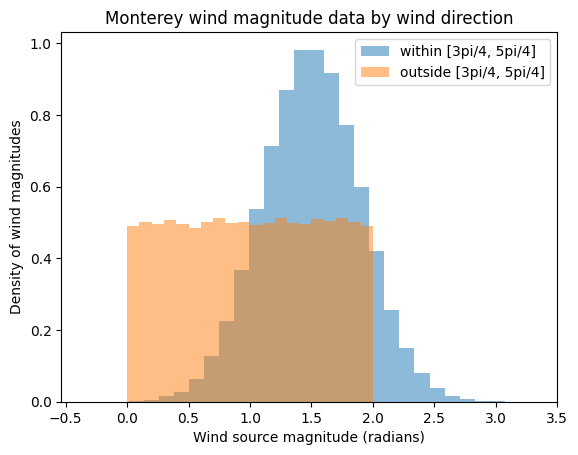

In [25]:
# model wind magnitude deviation at most frequent wind directions
md_wind_mag_gauss = (
    gr.Model()
    >> gr.cp_marginals(
        magnitude=gr.marg_mom(
            dist="norm",
            mean=1.5,
            sd=0.4,
        )
    )
    >> gr.cp_copula_independence()
)
df_wind_mag_gauss = (
    md_wind_mag_gauss
    >> gr.ev_sample(n=1e5, df_det="nom", skip=True, seed=101)
    >> gr.tf_mutate(id=DF.index)
)

# model wind magnitude deviation at less frequent wind directions
md_wind_mag_uniform = (
    gr.Model()
    >> gr.cp_marginals(
        magnitude=gr.marg_mom(
            dist="uniform",
            lo=0,
            up=2,
        )
    )
    >> gr.cp_copula_independence()
)
df_wind_mag_uniform = (
    md_wind_mag_uniform
    >> gr.ev_sample(n=1e5, df_det="nom", skip=True, seed=101)
    >> gr.tf_mutate(id=DF.index)
)

# plot wind magnitude variations
plt.figure()

plt.hist(df_wind_mag_gauss["magnitude"], bins=30, density=True, alpha=0.5, label="within [3pi/4, 5pi/4]")
plt.hist(df_wind_mag_uniform["magnitude"], bins=20, density=True, alpha=0.5, label="outside [3pi/4, 5pi/4]")

plt.legend()
plt.xlabel("Wind source magnitude (radians)")
plt.ylabel("Density of wind magnitudes")
plt.title("Monterey wind magnitude data by wind direction")
plt.show()

Because the model elects to use the green distribution for wind direction, which only includes values within the $[\frac{3\pi}{4},\frac{5\pi}{4}]$ range, it makes sense to select the magnitude distribution representing values in that range as well. Therefore, the model will use the blue distribution shown to model disturbance magnitudes. Unlike direction, which is treated as a constant per-scenario, magnitude of disturbance is resampled per-timestep to reflect realistic on-water variation of waves during field tests.

##### 4.4d Injecting Uncertainty to Form the Probabilistic Model

Now that all sources of uncertainty have either been abstracted as deterministic or explciitly modeled as random variables, they can be added to the deterministic model to form the probabilistic model.

In [46]:
# add uncertainty to make the ASV model probabilistic
md_asv_prob = (
    # deterministic model
    md_asv_det
    # add uncertainty to per-timestep motor commands
    >> gr.cp_marginals(
        **{f"v{k}_noise": gr.marg_mom(dist="norm", mean=0, var=0.10) for k in range(timesteps)}
    )
    >> gr.cp_marginals(
        **{f"w{k}_noise": gr.marg_mom(dist="norm", mean=0, var=0.10) for k in range(timesteps)}
    )
    # add uncertainty to per-timestep disturbance magnitude
    >> gr.cp_marginals(
        **{f"d_mag{k}": gr.marg_mom(dist="norm", mean=1.5, sd=0.4) for k in range(timesteps)},
    )
    # add uncertainty to initial disturbance direction
    >> gr.cp_marginals(
        d_ang=gr.marg_mom(
            dist="norm",
            mean=math.pi,
            var=0.3,
        )
    )
    # independence!
    >> gr.cp_copula_independence()
)

At this point, the model contains all desired objective functions driven by constrained decision variables and random variables representing sources of uncertainties. With this tool, the optimal solution under uncertain conditions can now be found.

## 5 Optimization Solution and Results Discussion

### 5.1 Finding the Optimal Control Vector

#### 5.1a Uncertainty Propagation

Rather than directly optimizing over a model that contains random variables, we must instead summarize the key characteristics of the uncertainty present and describe how they manifest in the objective functions. In the case of this project, for example, this means we aren't actually finding an optimal control vector to minimize the ASV's cumulative distance from the waypoint directly. Instead, we find an optimal control vector to minimize the ASV's *expected* cumulative distance from the waypoint, given the uncertainty present in the ASV's motor signal and environmental conditions. This is also true for energy consumption, which the model must minimize the expected outcome of rather than a specific value.

In the code below, expected values for both objective functions are approximated using Monte Carlo sampling and summarized within the model for future optimization.

In [47]:
md_asv_propagated = (
    gr.Model()
    >> gr.cp_vec_function(
        # Monte Carlo simulation
        fun=lambda df: gr.eval_sample(
            md_asv_prob, 
            df_det=df
            >> gr.tf_mutate(id=DF.index),
            n=20,
            seed=42,
            comm=True,
        )
        # summarize the Monte Carlo distribution
        >> gr.tf_group_by(DF.id)
        >> gr.tf_summarize(
            D_mean=gr.mean(DF.D),
            D_sd=gr.sd(DF.D),
            J_mean=gr.mean(DF.J),
            J_sd=gr.sd(DF.J),
        )
        >> gr.tf_ungroup(),
        # original model inputs and outputs, but with expected/SD values
        var=controls,
        out=["D_mean", "D_sd", "J_mean", "J_sd"],
    )
    # reconstrain linear velocity commands
    >> gr.cp_bounds(
        **{f"v{k}": (-0.0, +V_MAX) for k in range(timesteps)}
    )
    # reconstrain angular velocity commands
    >> gr.cp_bounds(
        **{f"w{k}": (-W_MAX, +W_MAX) for k in range(timesteps)}
    )
)

#### 5.1b Performing Optimization Under Uncertainty

The optimization peformed below is constrained, multi-objective, and under uncertainty. Constraints are applied within the model itself above. To perform multi-objective optimization, the lexicographic method is applied to ensure that the stakeholders' primary objective, cumulative distance to the waypoint, is prioritized over their secondary objective to minimize energy confumption in transit. Finally, expected values of objective functions are optimized after uncertainty was propagated through the model. Additionally, several restarts are used for each optimization step to encourage the model to avoid selecting suboptimal but locally optimal control vectors for its final output. 

In [ ]:
%%capture

# minimize expectation of D (cumulative distance from waypoint)
df_single_out: pd.DataFrame = (
    md_asv_propagated
    >> gr.ev_min(
        out_min="D_mean",
        n_restart=5,
    )
)
opt_val_D = df_single_out["D_mean"].min()

# minimize expectation of J (energy consumed)
df_multi_out: pd.DataFrame = (
    md_asv_propagated
    # lexicographic method -- constrain by optimal expected D
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            Dtol_leq=df["D_mean"] - opt_val_D - tol,
        ),
        var=["D_mean"],
        out=["Dtol_leq"],
    )
    >> gr.ev_min(
        out_min="J_mean",
        n_restart=5,
        out_leq=["Dtol_leq"],
    )
)
control_opt_DJ = df_multi_out[controls].loc[df_multi_out["D_mean"].idxmin()]

### 5.2 Optimization Results

In this section, the results of the optimization process are shown. The performance of the optimal control vector is compared against two baselines: zero control and random control. The performance is then discussed in the broader context of an autonomy stack, as well as in reference to stakeholder concerns.

#### 5.2a Evaluation of Optimal Control Vector

To evaluate the optimal control vector, 100 possible scenarios of random variable values will be sampled from the underlying probabilistic model using Monte Carlo methods. The resultant trajectories of applying the optimal control vector in each scenario are then plotted on a shared graph to display the overall trends created by the optimal vector. These sample scenarios will also be used to evaluate the two baseline control vectors described above.

In [80]:
def plot_probabilistic_trajectories(
    control_vec,
    md_prob,
    color,
    title,
    n_samples=5,
    seed=42,
):
    """
    Sample n_samples random variable vectors from the probabilistic model,
    simulate trajectories using the given (fixed) control vector, and plot them.
    """
    # --- sample random variables from the probabilistic model ---
    rv_samples = gr.eval_sample(
        md_prob,
        df_det=pd.DataFrame([control_vec]),
        n=n_samples,
        seed=seed,
        comm=False,
    )

    # --- plot fixed landmarks ---
    fig, ax = plt.subplots()
    ax.plot(
        deployment_state[0],
        deployment_state[1],
        "*",
        markersize=20,
        label="deployment",
        color="red",
        zorder=3,
    )
    ax.plot(
        waypt[0], waypt[1], "*", markersize=20, label="waypoint", color="lime", zorder=3
    )

    # --- simulate and plot one trajectory per sample row ---
    for i, (_, row) in enumerate(rv_samples.iterrows()):
        state_sequence = prob_state_transition(deployment_state, row)
        x_vec = [s[0] for s in state_sequence]
        y_vec = [s[1] for s in state_sequence]
        th_vec = [s[2] for s in state_sequence]

        ax.plot(x_vec, y_vec, alpha=0.2, c=color)

    ax.set_xlabel("X position (m)")
    ax.set_ylabel("Y position (m)")
    ax.set_title(f"Probabilistic Trajectories Using {title} (n={n_samples} samples)")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


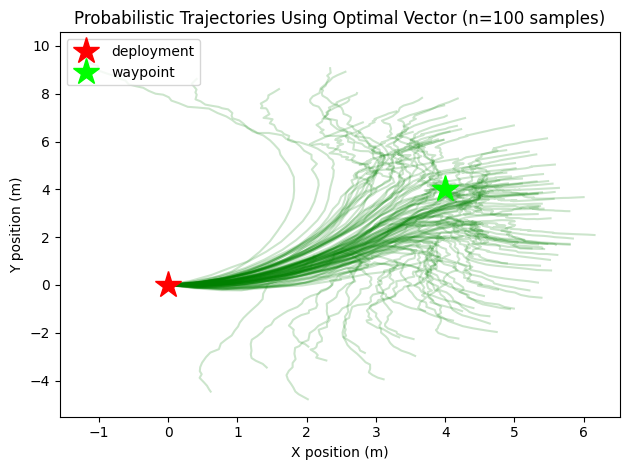

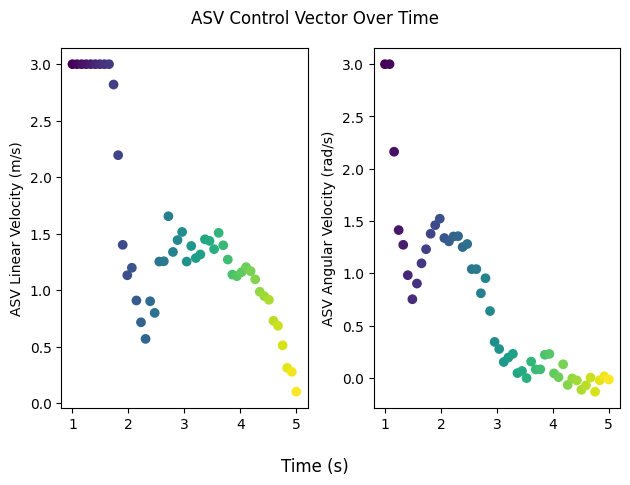

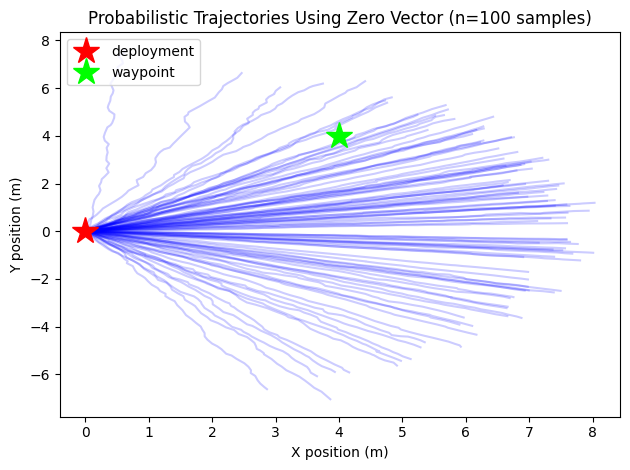

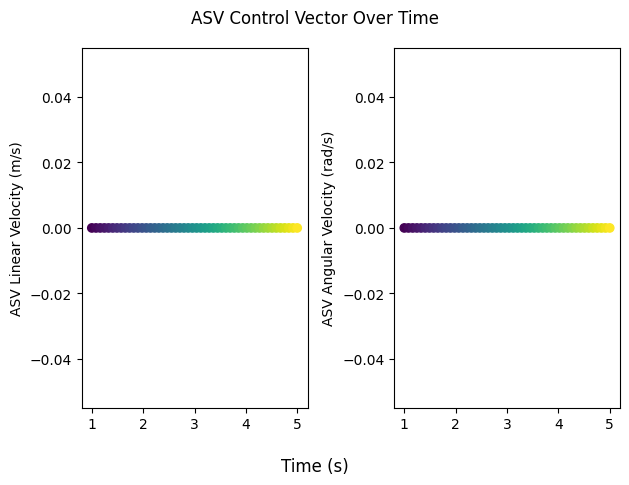

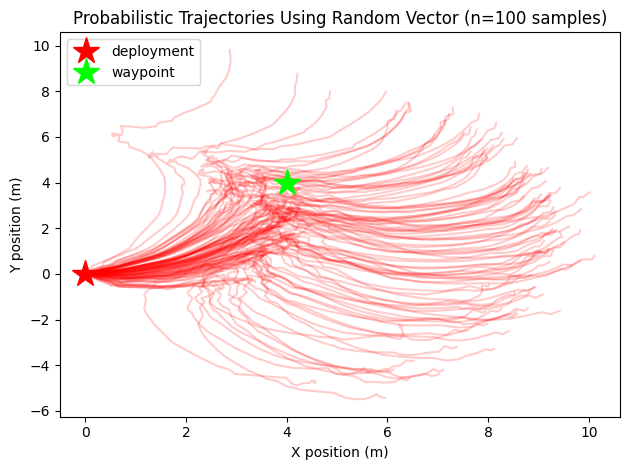

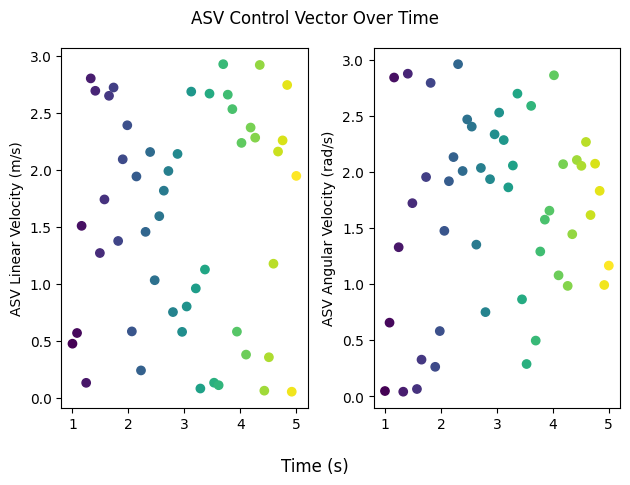

In [81]:
# OPTIMAL CONTROL VECTOR
plot_probabilistic_trajectories(
    control_vec=control_opt_DJ,  # your optimal control row
    md_prob=md_asv_prob,
    color="green",
    title="Optimal Vector",
    n_samples=100,
    seed=42,
)

viz.plot_control_vector(
    control_opt_DJ,
    total_time,
    timesteps,
    )
plt.show()

# ZERO CONTROL VECTOR
zero_control_vec = pd.Series(0,index=control_opt_DJ.index)
plot_probabilistic_trajectories(
    control_vec=zero_control_vec,  # your optimal control row
    md_prob=md_asv_prob,
    color="blue",
    title="Zero Vector",
    n_samples=100,
    seed=42,
)

viz.plot_control_vector(
    zero_control_vec,
    total_time,
    timesteps,
    )
plt.show()

# RANDOM CONTROL VECTOR
rng = np.random.default_rng()
rng_control_vec = pd.Series(rng.uniform(0,V_MAX,len(control_opt_DJ)),index=control_opt_DJ.index)
plot_probabilistic_trajectories(
    control_vec=rng_control_vec,  # your optimal control row
    md_prob=md_asv_prob,
    color="red",
    title="Random Vector",
    n_samples=100,
    seed=42,
)

viz.plot_control_vector(
    rng_control_vec,
    total_time,
    timesteps,
    )
plt.show()

The navigational plot above shows the nominal trajectory created by the optimal control vector under 100 samples of possible scenarios, with involves variation in motor noise, disturbance direction, and disturbance magnitude. The regions with the densest color are the most common resultant trajectories, but all visible trajectories are possible under the uncertain conditions of the environment.

Below that plot, the optimal vector values are plotted with respect to time. Both the linear velocity and angular velocity sequence begin at high values, as the control vector pushes for minimal distance from the waypoint as quickly as possible. Over the course of the trajectory, both vectors drop to moderate values, which presumably work well across the variety of possible scenarios the ASV might be in. Angular velocity reduces to a near-zero steady state more quickly, but linear velocity remains nonzero until almost the end of the timespan, as fewer and fewer ASVs remain in scenarios in which they have not converged onto the waypoint.

The following plots compare the optimal control vector's performance to two baseline control vectors. In the first, a zero-output control vector, the ASV's position is exclusively a function of the uncertain environmental disturbances. As such, only in the rare case that the environmental disturbance aligns with the ASV-waypoint line does the ASV reach the waypoint. In the second, a random-output control vector, the ASV ends up in range of the waypoint more often than with the zero-output vector, but it leaves the waypoint quickly and frequently, making its initial chance of success meaningless.

#### 5.2b Results in Context - System and Stakeholders

Overall, the model results look promising. While several trajectories seem to take the ASV away from the waypoint, the vast majority of trajectories mobilize the ASV towards the waypoint in an expected, spline-like curve and generally remain in the area upon reaching the waypoint. Overshooting seems to be a bigger problem under the uncertain model compared to the deterministic model; this is likely due to high variability in the magnitude of disturbances, which makes it difficult to precisely land at a given spot.

As a reminder, in the broader context of an autonomy stack, the local planner model's purpose is only to produce a nominal, open-loop control vector for a controller to iterate upon later. In this context, the results seem to show a significant reduction in future work for a real-time controller to correct a a nominal trajectory. This is because the optimal control vector is generally much better at closing the distance between the ASV and the waypoint promptly, in comparison to the baseline control vectors. In future work, it would be worth exploring the optimization of standard deviation of objective functions rather than expected functions, if robustness is desired over a quality expected value.

When considering the model's three primary stakeholders -- the shore research team, the field deployment team, and the ecosystem -- the results seem to all three groups' desired outcomes. The shore research team's primary concern regarding reaching waypoints seems to be sufficiently met for a nominal trajectory setting up a future controller for success, as discussed above. Additionally, velocity commands are smooth and nearly never operating at maximum, which is promising for the field deployment team's desire for efficient energy consumption and the ecosystem's desire for minimal disturbance. The secondary concern of the field deployment team for fast missions also seems sufficient, as the ASV reliably arrives at the waypoint before running out of operating time. Again, with more time, it would be worth exploring the comparative quality of optimizing for minimal standard deviation values of objective functions rather than expectations, to see if those results better address stakeholder concerns.

The limitations of the current optimal solution seem related to the anticipated limitations established at the beginning of the report. In particular, the choice to model wind direction as a per-scenario constant means that this model's solution would be even more vulnerable to environmental uncertainty than it already seems to be. This model also only captures the most likely range of directons (west-blowing), meaning that actual performance in the field would be substantially more varied. However, this is still an acceptable limitation given that the model is only meant to reduce strain on a real-time controller, meaning that any amount of performance improvement over the baselines can be considered valuable.

## 6 Conclusion, Limitations, and Future Work

### 6.1 Summary of Results

In summary, optimization of the model's expected objective function values resulted in an optimal control vector that reliably produced efficient nominal trajectories. While several trajectories do not result in the ASV arriving at the waypoint, the vast majority of trajectories mobilize the ASV towards the waypoint in an smooth, spline-like curve and generally remain nearby once the ASV has arrived. The optimal control vector substantially outperformed two baseline control vector examples, including a zero-output vector and a random-output vector. Primary stakeholder concerns, including consistent waypoint arrivals, minimal energy consumption, and minimal elapsed time, are all sufficiently met by the model's solution.

### 6.2 Ethical Practice

I think that the personal value of mine most strongly reflected in my design decisions for this model is the emphasis I place on understanding technology in a systems context. I believe it is a mistake to assume that any piece of technology exists in a vaccuum, and that everything must be understood in context, whether that context is systematic, moral, or something else. For example, in this project, several of my design choices were made with the knowledge that this model would exist in close partnership with higher-level autonomy (i.e. a global planner) and lower-level autonomy (i.e. a controller). My design choices were based on trust of the capabilities of those systems, and an experiential understanding that clearly delineating system boundaries, inputs, and outputs leads to smoother and more modular complex systems in the long run. In addition to placing my model in its systems context, I also contextualized the model within the academic and scientific value it was designed to produce.

For me, these values connect to the in-class discussions surrounding imagination. Too often, modeling abstractions are made carelessly when the underlying motivation to make them is to avoid imagination. By choosing to imagine my model's broader academic, scientific, and environmental impact, rather than only examining immediate impact on decontextualized results, I was able to better identify critical priorities that drove my decision-making.

I also think that my commitment to contextualizing my model in a broader autonomy stack was driven by our in-class discussions on technomoral humility. My original model was much more complex, and strove to span all three modules in the navigation stack, but ultimately reduced the scope of my model in an acknowledgement that a single optimization problem shouldn't hope to capture the multi-dimensional complexity of robot navigation. In that sense, technomoral humility was reflected in my acknowledgement of the limitations of optimization and model formulation itself.

### 6.3 Future Work

Finally, here is a short list of model improvements and applications to explore with more time:
- Explore optimization over standard deviation rather than expectation of objective functions
- Refine disturbance uncertainty modeling with Gaussian mixtures
- Budget time for higher numbers of evaluation restarts to bolster solution confidence
- Expand or clone the model to handle waypoint sequences
- Redesign model kinematics as forces rather than velocities and compare results
- Couple the model with a controller module and evaluate how it affects the controller's performance

#### 7 Appendix and Source Code
[Full Source Code](https://github.com/itannermahncke/trajectory-optimization-under-uncertainty)

[Wind Rose Data Source](https://www.meteoblue.com/)